# Mesh Curvature Instance Segmentation Tutorial

This tutorial relies on Google Colab to perform the segmentation on the mesh. Please note that the visualization capabilitie of Google Colab are limited (i.e., online viewer may be slow).

In [ ]:
!git clone https://github.com/UP-RS-ESP/mesh-curvature-instance-segmentation.git

Cloning into 'mesh-curvature-instance-segmentation'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 38 (delta 8), reused 11 (delta 2), pack-reused 10 (from 1)
Receiving objects: 100% (38/38), 58.89 MiB | 16.38 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Updating files: 100% (9/9), done.


In [ ]:
!pip install open3d scipy matplotlib tqdm numpy pandas
!cd /content/mesh-curvature-instance-segmentation

In [ ]:
import sys
sys.path.append('/content/mesh-curvature-instance-segmentation')

import numpy as np
import open3d as o3d
import mesh_curvature_instance_segmentation as seg
import matplotlib.pyplot as pl

In [ ]:
fn = "mesh-curvature-instance-segmentation/sandbox_subset.ply"
mesh = o3d.io.read_triangle_mesh(fn)
mesh.compute_vertex_normals()
o3d.visualization.draw_plotly([mesh])

## Run Instance Segmentation

In [ ]:
mesh_seg, tri_seg, vrt_seg, colors = seg.instance_segmentation(mesh,
    surface_area_threshold=1e-4,
    erosion=True,
    erosion_iterations=1,
    dilation=True,
    dilation_iterations=3,
)

total surface area: 0.25284569114589295
average surface area per triangle: 7.591080745313413e-08
surface area threshold in number of triangles: 1317
compute surface normal divergence as mean surface curvature
removing large vertical triangles
erode potential segments in order to remove bridges
filter by sphericity


100%|██████████| 145/145 [00:01<00:00, 73.77it/s] 


dilation, undo erosion of segments


100%|██████████| 146005/146005 [00:02<00:00, 54872.90it/s]


fill topological holes in segments


100%|██████████| 5663/5663 [00:06<00:00, 860.05it/s]


final components as segments
neighborhood graph based segment coloring


100%|██████████| 143/143 [00:00<00:00, 197.48it/s]


In [ ]:
o3d.visualization.draw_plotly([mesh_seg])

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
rgb_map = np.array(
    [[1.000, 0.871, 0.678],
     [0.973, 0.718, 0.600],
     [0.737, 0.839, 0.753],
     [0.941, 0.502, 0.502],
     [0.733, 0.608, 0.718],
     [0.690, 0.678, 0.686],
     [0.275, 0.753, 0.843],
     [0.000, 0.557, 0.788],
     [0.392, 0.898, 0.898]]
)

mesh_seg.vertex_colors = o3d.utility.Vector3dVector(rgb_map[colors])
o3d.visualization.draw_plotly([mesh, mesh_seg])

In [ ]:
#Alternative visualization using webrt (but requires installation and compilation of local software)
#o3d.visualization.webrtc_server.enable_webrtc()
#draw([mesh])

In [ ]:
fn = "mesh-curvature-instance-segmentation/sandbox_subset.ply"
o3d.io.write_triangle_mesh(fn[:-4] + "_segments.ply", mesh_seg, compressed=True)
np.save(fn[:-4] + "_segments_label_facets.npy", tri_seg)
np.save(fn[:-4] + "_segments_label_vertex.npy", vrt_seg)
np.save(fn[:-4] + "_segments_label_colors.npy", colors)

## Segment Statistics

In [ ]:
# read mesh and segments
fn = "/content/mesh-curvature-instance-segmentation/sandbox_subset_segments.ply"
mesh = o3d.io.read_triangle_mesh(fn)
vrt_seg = np.load(fn[:-4] + "_label_vertex.npy")
colors = np.load(fn[:-4] + "_label_colors.npy")

# compute statistics
stats_dict = seg.segment_statistics(mesh, vrt_seg, colors, write_segments=True)

# write statistics to a CSV file
seg.dict_to_csv(fn[:-4] + "_segment_stats.csv", stats_dict)

100%|██████████| 143/143 [00:34<00:00,  4.12it/s]


In [ ]:
# also individual segments are stored with "write_segments=True"
segment = o3d.io.read_triangle_mesh("segment_0004.ply")
segment.compute_vertex_normals()
o3d.visualization.draw_plotly([segment])

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import pandas as pd


# read segment statistics
df = pd.read_csv("/content/mesh-curvature-instance-segmentation/sandbox_subset_segments_segment_stats.csv")
df

,Unnamed: 0,segment id,segment color,centroid x,centroid y,centroid z,A axis,B axis,C axis,yaw,...,red mean,green mean,blue mean,red std,green std,blue std,mesh surface area,convex hull area,convex hull volume,convex hull sphericity
0,0,0,0,0.054029,-0.350354,0.043422,0.048460,0.043135,0.041514,159.870218,...,1.000000,0.870588,0.678431,0.000000e+00,5.895284e-14,9.559020e-14,0.001443,0.004974,2.510016e-05,0.833561
1,1,1,1,0.082773,-0.312401,0.074019,0.067775,0.060272,0.047835,-142.223141,...,0.972549,0.717647,0.600000,7.546186e-13,2.232659e-13,6.620260e-13,0.007778,0.010917,9.659942e-05,0.932567
2,2,2,0,0.041097,-0.218386,0.075632,0.147602,0.085023,0.062595,143.065490,...,1.000000,0.870588,0.678431,0.000000e+00,7.540635e-13,7.085443e-13,0.015792,0.028702,3.135480e-04,0.777626
3,3,3,0,0.248462,-0.397295,0.038053,0.032689,0.024340,0.020789,-114.963766,...,1.000000,0.870588,0.678431,0.000000e+00,6.850076e-14,2.442491e-14,0.001232,0.002028,7.535814e-06,0.916598
4,4,4,0,0.100860,-0.428295,0.094282,0.143096,0.099409,0.092212,153.515867,...,1.000000,0.870588,0.678431,0.000000e+00,8.839596e-13,1.375566e-12,0.027150,0.036250,5.819676e-04,0.929911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,138,138,3,0.192755,-0.230214,0.032917,0.013043,0.012149,0.006046,179.342331,...,0.941176,0.501961,0.501961,3.030909e-14,1.665335e-15,1.665335e-15,0.000158,0.000324,3.678617e-07,0.766826
139,139,139,1,0.216206,-0.179946,0.056425,0.034508,0.018550,0.007932,-166.070641,...,0.972549,0.717647,0.600000,2.242651e-14,2.331468e-15,3.175238e-14,0.000532,0.001268,2.302651e-06,0.665118
140,140,140,1,0.208259,-0.231635,0.043069,0.030830,0.009887,0.009478,-139.591401,...,0.972549,0.717647,0.600000,2.176037e-14,1.665335e-14,1.476597e-14,0.000262,0.000665,9.927177e-07,0.724110
141,141,141,3,0.044371,-0.464072,0.045432,0.019612,0.011763,0.008229,-113.376312,...,0.941176,0.501961,0.501961,2.431388e-14,1.665335e-15,1.665335e-15,0.000127,0.000387,4.710451e-07,0.756146


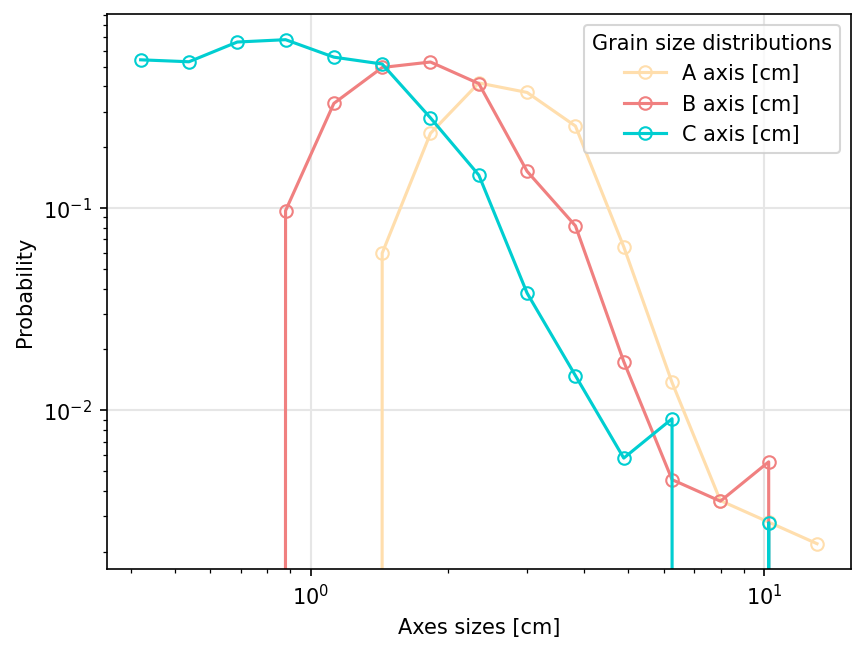

In [ ]:
# colors
cc = "darkturquoise"
cb = "lightcoral"
ca = "navajowhite"

# read axes and convert to cm
dc = df["C axis"].to_numpy() * 100
db = df["B axis"].to_numpy() * 100
da = df["A axis"].to_numpy() * 100

# logarithmic bins
n = 15
dmin = min(min(dc.min(), db.min()), da.min())
dmax = max(max(dc.max(), db.max()), da.max())
bins = np.logspace(np.log10(dmin), np.log10(dmax), n*2+1)[::2]
binc = np.logspace(np.log10(dmin), np.log10(dmax), n*2+1)[1::2]

# histograms
pda, _ = np.histogram(da, bins=bins, density=True)
pdb, _ = np.histogram(db, bins=bins, density=True)
pdc, _ = np.histogram(dc, bins=bins, density=True)

# figure
pl.figure(dpi=150)
pl.loglog(binc, pda, marker="o", mfc="none", color=ca, label="A axis [cm]")
pl.loglog(binc, pdb, marker="o", mfc="none", color=cb, label="B axis [cm]")
pl.loglog(binc, pdc, marker="o", mfc="none", color=cc, label="C axis [cm]")
pl.ylabel("Probability")
pl.xlabel("Axes sizes [cm]")
pl.grid(lw=1, color="0.9")
pl.legend(
    loc="upper right",
    title="Grain size distributions"
)
pl.show()